# 4 S/C Dispersion Relation
author: Louis Richard\


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from pyrfu import mms, pyrf
from pyrfu.plot import plot_spectr

Load IGRF coefficients ...


## Define time interval, and data path

In [2]:
mms.db_init(default="local", local="/Volumes/mms")
tint = ["2015-10-16T13:05:24.000", "2015-10-16T13:05:50.000"]

[27-Feb-26 15:38:49] INFO: Updating MMS data access configuration in /Users/louisr/Dropbox/Documents/irfu-python/.venv/lib/python3.14/site-packages/pyrfu/mms/config.json...
[27-Feb-26 15:38:49] INFO: Updating MMS SDC credentials in /Users/louisr/.config/python_keyring...


# Load data

## Load FGM and SCM magnetic fields

In [3]:
b_xyz_mms = [mms.get_data("b_gse_fgm_brst_l2", tint, ic) for ic in range(1, 5)]
b_scm_mms = [mms.get_data("b_gse_scm_brst_l2", tint, ic) for ic in range(1, 5)]

[27-Feb-26 15:38:49] INFO: Loading mms1_fgm_b_gse_brst_l2...
[27-Feb-26 15:38:49] INFO: Loading mms2_fgm_b_gse_brst_l2...
[27-Feb-26 15:38:49] INFO: Loading mms3_fgm_b_gse_brst_l2...
[27-Feb-26 15:38:49] INFO: Loading mms4_fgm_b_gse_brst_l2...
[27-Feb-26 15:38:49] INFO: Loading mms1_scm_acb_gse_scb_brst_l2...
[27-Feb-26 15:38:50] INFO: Loading mms2_scm_acb_gse_scb_brst_l2...
[27-Feb-26 15:38:50] INFO: Loading mms3_scm_acb_gse_scb_brst_l2...
[27-Feb-26 15:38:51] INFO: Loading mms4_scm_acb_gse_scb_brst_l2...


## Load spacecraft positions 

In [4]:
tint_long = pyrf.extend_tint(tint, [-60, 60])
r_xyz_mms = [mms.get_data("r_gse_mec_srvy_l2", tint_long, ic) for ic in range(1, 5)]

[27-Feb-26 15:38:51] INFO: Loading mms1_mec_r_gse...
[27-Feb-26 15:38:51] INFO: Loading mms2_mec_r_gse...
[27-Feb-26 15:38:51] INFO: Loading mms3_mec_r_gse...
[27-Feb-26 15:38:51] INFO: Loading mms4_mec_r_gse...


# Convert SCM magnetic field to field-aligned coordinates

In [5]:
b_xyz_avg = pyrf.avg_4sc(b_xyz_mms)
b_fac_mms = [pyrf.convert_fac(b_scm, b_xyz_avg, [1, 0, 0]) for b_scm in b_scm_mms]

# Compute 4 s/c dispersion relation

## Define time interval of wave burst

In [6]:
tints = ["2015-10-16T13:05:26.500", "2015-10-16T13:05:27.000"]

## Get a perpandicular component of the fluctuating magnetic field

In [7]:
b_para_mms = [b_fac[:, 0] for b_fac in b_fac_mms]

## Calculate 4 s/c dispersion relation

In [8]:
f_range = [300.0, 1000.0]
power = mms.fk_power_spectrum_4sc(
    b_para_mms,
    r_xyz_mms,
    b_xyz_mms,
    tints,
    df=10.0,
    num_k=500,
    cav=4,
    w_width=2.0,
    f_range=f_range,
)

[27-Feb-26 15:38:59] WARNING: /Users/louisr/Dropbox/Documents/irfu-python/.venv/lib/python3.14/site-packages/pyrfu/mms/fk_power_spectrum_4sc.py:168: ComplexWarning: Casting complex values to real discards the imaginary part
  fk_power += (w[i].data * np.conj(w[i].data) / 4).astype(np.float64)

[27-Feb-26 15:39:43] INFO: Computing power versus (kx,f); (ky,f), (kz,f), (k,f)
[27-Feb-26 15:39:44] INFO: Computing power versus (kx,ky); (kx,kz); (ky,kz)
[27-Feb-26 15:39:44] INFO: Computing power versus kperp,kpara


## Change units of wavevector and frequency (for plotting)

In [9]:
# Change units of wave vector and frequency of the power spectrum to 1/km and kHz, respectively
power = power.assign_coords(
    k_mag=power.k_mag.data * 1e3,
    k_x=power.k_x.data * 1e3,
    k_y=power.k_y.data * 1e3,
    k_z=power.k_z.data * 1e3,
    k_perp=power.k_perp.data * 1e3,
    k_para=power.k_para.data * 1e3,
)
power = power.assign_coords(f=power.f.data * 1e-3)

# Change units of wave vector and frequency of the peak power
power.attrs = {
    key: value * 1e3 if "k_" in key else value * 1e-3
    for key, value in power.attrs.items()
}

# Plot

Text(0.5, 0, '$P(k_y, k_z)/P_{max}$')

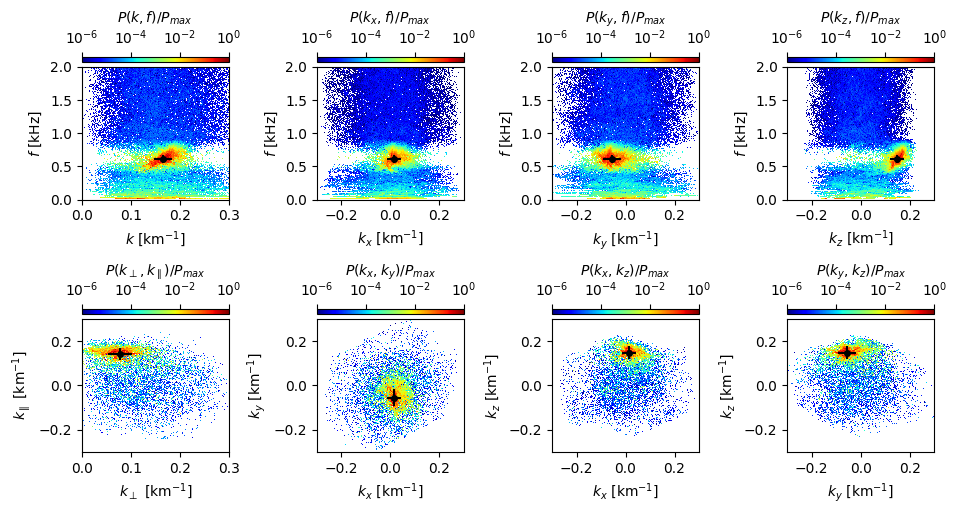

In [10]:
f, axs = plt.subplots(2, 4, figsize=(11, 5))
f.subplots_adjust(wspace=0.6, hspace=0.9)

f_lim = [
    0,
]
axs[0, 0], cax00 = plot_spectr(
    axs[0, 0], power.k_mag_f, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[0, 0].axhline(f_range[0], color="gray", linestyle="--")
axs[0, 0].axhline(f_range[1], color="gray", linestyle="--")
axs[0, 0].errorbar(
    power.attrs["k_mag_avg"],
    power.attrs["f_avg"],
    xerr=power.attrs["k_mag_std"],
    yerr=power.attrs["f_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[0, 0].set_xlim([0, 0.3])
axs[0, 0].set_ylim([0, 2])
axs[0, 0].set_xlabel(r"$k~[\mathrm{km}^{-1}]$")
axs[0, 0].set_ylabel(r"$f~[\mathrm{kHz}]$")
cax00.set_xlabel(r"$P(k, f)/P_{max}$")

axs[0, 1], cax01 = plot_spectr(
    axs[0, 1], power.k_x_f, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[0, 1].axhline(f_range[0], color="gray", linestyle="--")
axs[0, 1].axhline(f_range[1], color="gray", linestyle="--")
axs[0, 1].errorbar(
    power.attrs["k_x_avg"],
    power.attrs["f_avg"],
    xerr=power.attrs["k_x_std"],
    yerr=power.attrs["f_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[0, 1].set_xlim([-0.3, 0.3])
axs[0, 1].set_ylim([0, 2])
axs[0, 1].set_xlabel(r"$k_x~[\mathrm{km}^{-1}]$")
axs[0, 1].set_ylabel(r"$f~[\mathrm{kHz}]$")
cax01.set_xlabel(r"$P(k_x, f)/P_{max}$")

axs[0, 2], cax02 = plot_spectr(
    axs[0, 2], power.k_y_f, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[0, 2].axhline(f_range[0], color="gray", linestyle="--")
axs[0, 2].axhline(f_range[1], color="gray", linestyle="--")
axs[0, 2].errorbar(
    power.attrs["k_y_avg"],
    power.attrs["f_avg"],
    xerr=power.attrs["k_y_std"],
    yerr=power.attrs["f_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[0, 2].set_xlim([-0.3, 0.3])
axs[0, 2].set_ylim([0, 2])
axs[0, 2].set_xlabel(r"$k_y~[\mathrm{km}^{-1}]$")
axs[0, 2].set_ylabel(r"$f~[\mathrm{kHz}]$")
cax02.set_xlabel(r"$P(k_y, f)/P_{max}$")

axs[0, 3], cax03 = plot_spectr(
    axs[0, 3], power.k_z_f, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[0, 3].axhline(f_range[0], color="gray", linestyle="--")
axs[0, 3].axhline(f_range[1], color="gray", linestyle="--")
axs[0, 3].errorbar(
    power.attrs["k_z_avg"],
    power.attrs["f_avg"],
    xerr=power.attrs["k_z_std"],
    yerr=power.attrs["f_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[0, 3].set_xlim([-0.3, 0.3])
axs[0, 3].set_ylim([0, 2])
axs[0, 3].set_xlabel(r"$k_z~[\mathrm{km}^{-1}]$")
axs[0, 3].set_ylabel(r"$f~[\mathrm{kHz}]$")
cax03.set_xlabel(r"$P(k_z, f)/P_{max}$")


axs[1, 0], cax10 = plot_spectr(
    axs[1, 0],
    power.k_perp_k_para,
    cscale="log",
    cmap="jet",
    clim=[1e-6, 1e0],
    colorbar="top",
)
axs[1, 0].errorbar(
    power.attrs["k_perp_avg"],
    power.attrs["k_para_avg"],
    xerr=power.attrs["k_perp_std"],
    yerr=power.attrs["k_para_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[1, 0].set_xlim([0, 0.3])
axs[1, 0].set_ylim([-0.3, 0.3])
axs[1, 0].set_xlabel(r"$k_\bot~[\mathrm{km}^{-1}]$")
axs[1, 0].set_ylabel(r"$k_\parallel~[\mathrm{km}^{-1}]$")
cax10.set_xlabel(r"$P(k_\bot, k_\parallel)/P_{max}$")

axs[1, 1], cax11 = plot_spectr(
    axs[1, 1], power.k_x_k_y, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[1, 1].errorbar(
    power.attrs["k_x_avg"],
    power.attrs["k_y_avg"],
    xerr=power.attrs["k_x_std"],
    yerr=power.attrs["k_y_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[1, 1].set_xlim([-0.3, 0.3])
axs[1, 1].set_ylim([-0.3, 0.3])
axs[1, 1].set_xlabel(r"$k_x~[\mathrm{km}^{-1}]$")
axs[1, 1].set_ylabel(r"$k_y~[\mathrm{km}^{-1}]$")
cax11.set_xlabel(r"$P(k_x, k_y)/P_{max}$")

axs[1, 2], cax12 = plot_spectr(
    axs[1, 2], power.k_x_k_z, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[1, 2].errorbar(
    power.attrs["k_x_avg"],
    power.attrs["k_z_avg"],
    xerr=power.attrs["k_x_std"],
    yerr=power.attrs["k_z_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[1, 2].set_xlim([-0.3, 0.3])
axs[1, 2].set_ylim([-0.3, 0.3])
axs[1, 2].set_xlabel(r"$k_x~[\mathrm{km}^{-1}]$")
axs[1, 2].set_ylabel(r"$k_z~[\mathrm{km}^{-1}]$")
cax12.set_xlabel(r"$P(k_x, k_z)/P_{max}$")

axs[1, 3], cax13 = plot_spectr(
    axs[1, 3], power.k_y_k_z, cscale="log", cmap="jet", clim=[1e-6, 1e0], colorbar="top"
)
axs[1, 3].errorbar(
    power.attrs["k_y_avg"],
    power.attrs["k_z_avg"],
    xerr=power.attrs["k_y_std"],
    yerr=power.attrs["k_z_std"],
    fmt="o",
    color="black",
    markersize=4,
)
axs[1, 3].set_xlim([-0.3, 0.3])
axs[1, 3].set_ylim([-0.3, 0.3])
axs[1, 3].set_xlabel(r"$k_y~[\mathrm{km}^{-1}]$")
axs[1, 3].set_ylabel(r"$k_z~[\mathrm{km}^{-1}]$")
cax13.set_xlabel(r"$P(k_y, k_z)/P_{max}$")